In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

data = np.load('boxplot_data.npz', allow_pickle=True)
num_annotations = data['budgets']
n_budgets = len(num_annotations)

/var/folders/sg/d0yh45390j9ct1_zwp6r1qx40000gn/T/ipykernel_3001/4100816358.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, patch_artist=True, labels=labels)


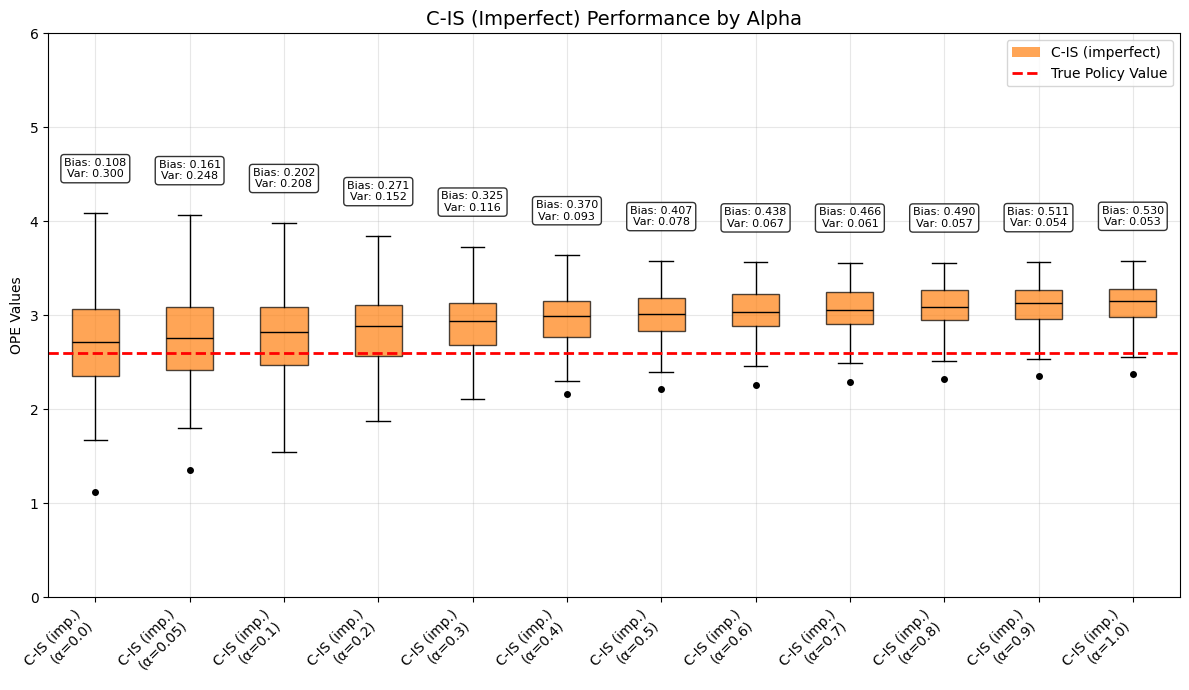

In [120]:
data = np.load('boxplot_data_alpha_3s5a.npz', allow_pickle=True)
alphas = data['alphas']
n_alphas = len(alphas)
true_value = data['true_value']

cis_imperfect_data = data['CIS_imperfect_estimates']

box_data = []
labels = []

for i, alpha in enumerate(alphas):
    box_data.append(cis_imperfect_data[:, i, -1])
    labels.append(f'C-IS (imp.)\n(α={alpha})')

color = '#ff7f0e'

fig, ax = plt.subplots(figsize=(12, 7))

bp = ax.boxplot(box_data, patch_artist=True, labels=labels)

for patch in bp['boxes']:
    patch.set_facecolor(color)
    patch.set_alpha(0.7)


for key in ['whiskers', 'caps', 'medians', 'fliers']:
    for item in bp[key]:
        item.set_color('black')
        if key == 'fliers':
            item.set_markerfacecolor('black')
            item.set_markeredgecolor('black')
            item.set_markersize(4)

ax.axhline(y=true_value, color='red', linestyle='--', linewidth=2, label='True Value')

legend_elements = [
    Patch(facecolor='#ff7f0e', alpha=0.7, label='C-IS (imperfect)'),
    Line2D([0], [0], color='red', linestyle='--', lw=2, label='True Policy Value')
]
ax.legend(handles=legend_elements, loc='upper right')


global_max = np.max([np.max(d) for d in box_data if len(d) > 0])
global_min = np.min([np.min(d) for d in box_data if len(d) > 0])
y_offset = (global_max - global_min) * 0.02

for i, estimates in enumerate(box_data):
    if len(estimates) == 0: continue

    mean_est = np.mean(estimates)
    abs_bias = mean_est - true_value
    variance = np.var(estimates)

    y_pos = np.max(estimates) + y_offset

    ax.text(i + 1, y_pos + 0.3, f'Bias: {abs_bias:.3f}\nVar: {variance:.3f}',
            ha='center', va='bottom', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_title('C-IS (Imperfect) Performance by Alpha', fontsize=14)
ax.set_ylabel('OPE Values', fontsize=10)
ax.grid(True, linestyle='-', alpha=0.3)

plt.xticks(rotation=45, ha='right')

plt.ylim([0,6])
plt.tight_layout()
plt.savefig('C-IS (Imperfect) Alpha Boxplot.png', dpi=300)
plt.show()

/var/folders/sg/d0yh45390j9ct1_zwp6r1qx40000gn/T/ipykernel_3001/1308435520.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, patch_artist=True, labels=labels)


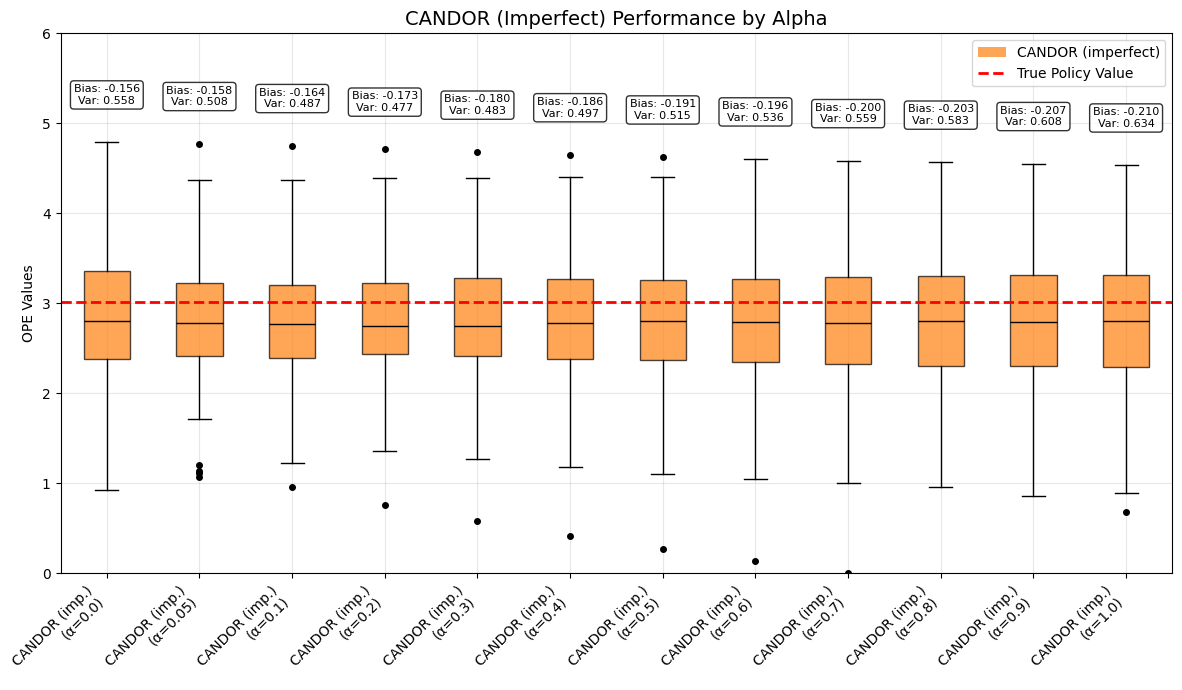

In [161]:
data = np.load('boxplot_data_alpha_3s5a.npz', allow_pickle=True)
alphas = data['alphas']
n_alphas = len(alphas)
true_value = data['true_value']

candor_imperfect_data = data['CANDOR_imperfect_estimates']

box_data = []
labels = []

for i, alpha in enumerate(alphas):
    box_data.append(candor_imperfect_data[:, i, -1])
    labels.append(f'CANDOR (imp.)\n(α={alpha})')

color = '#ff7f0e'

fig, ax = plt.subplots(figsize=(12, 7))

bp = ax.boxplot(box_data, patch_artist=True, labels=labels)

for patch in bp['boxes']:
    patch.set_facecolor(color)
    patch.set_alpha(0.7)


for key in ['whiskers', 'caps', 'medians', 'fliers']:
    for item in bp[key]:
        item.set_color('black')
        if key == 'fliers':
            item.set_markerfacecolor('black')
            item.set_markeredgecolor('black')
            item.set_markersize(4)

ax.axhline(y=true_value, color='red', linestyle='--', linewidth=2, label='True Value')

legend_elements = [
    Patch(facecolor='#ff7f0e', alpha=0.7, label='CANDOR (imperfect)'),
    Line2D([0], [0], color='red', linestyle='--', lw=2, label='True Policy Value')
]
ax.legend(handles=legend_elements, loc='upper right')


global_max = np.max([np.max(d) for d in box_data if len(d) > 0])
global_min = np.min([np.min(d) for d in box_data if len(d) > 0])
y_offset = (global_max - global_min) * 0.02

for i, estimates in enumerate(box_data):
    if len(estimates) == 0: continue

    mean_est = np.mean(estimates)
    abs_bias = mean_est - true_value
    variance = np.var(estimates)

    y_pos = np.max(estimates) + y_offset

    ax.text(i + 1, y_pos + 0.3, f'Bias: {abs_bias:.3f}\nVar: {variance:.3f}',
            ha='center', va='bottom', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_title('CANDOR (Imperfect) Performance by Alpha', fontsize=14)
ax.set_ylabel('OPE Values', fontsize=10)
ax.grid(True, linestyle='-', alpha=0.3)

plt.xticks(rotation=45, ha='right')

plt.ylim([0,6])
plt.tight_layout()
plt.savefig('CANDOR(Imperfect) Alpha Boxplot.png', dpi=300)
plt.show()

/var/folders/sg/d0yh45390j9ct1_zwp6r1qx40000gn/T/ipykernel_3001/90922846.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, patch_artist=True, labels=labels)


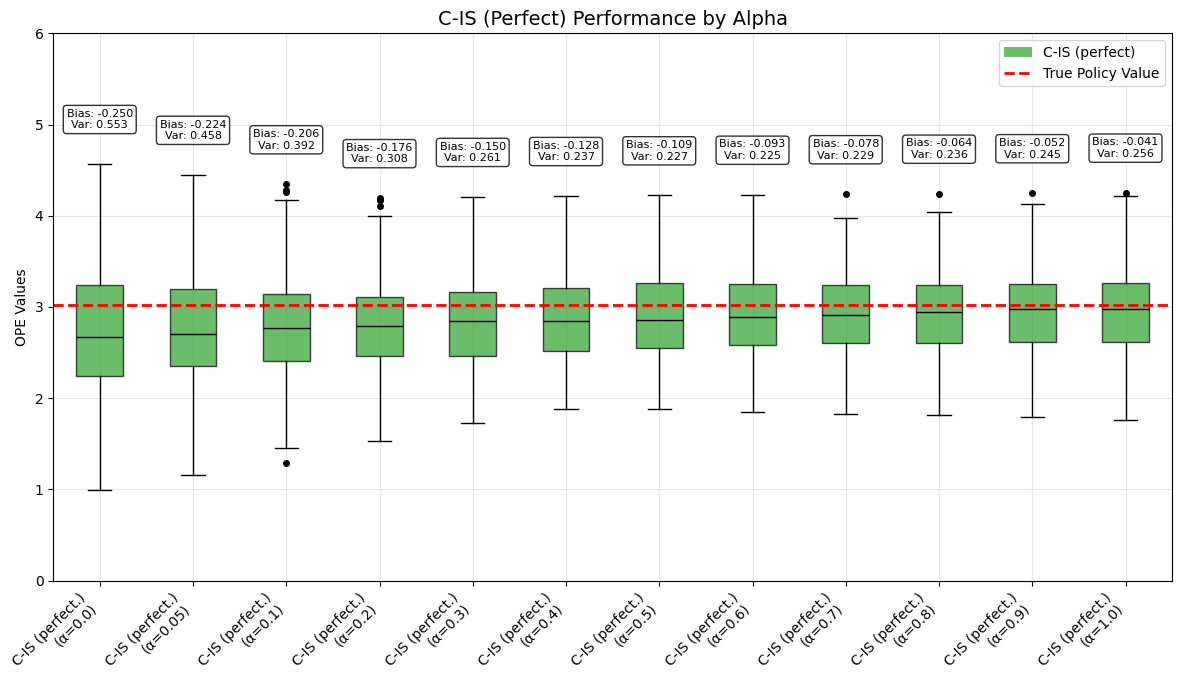

In [160]:
data = np.load('boxplot_data_alpha_3s5a.npz', allow_pickle=True)
alphas = data['alphas']
n_alphas = len(alphas)
true_value = data['true_value']

cis_imperfect_data = data['CIS_perfect_estimates']

box_data = []
labels = []

for i, alpha in enumerate(alphas):
    box_data.append(cis_imperfect_data[:, i, -1])
    labels.append(f'C-IS (perfect.)\n(α={alpha})')

color = '#2ca02c'

fig, ax = plt.subplots(figsize=(12, 7))

bp = ax.boxplot(box_data, patch_artist=True, labels=labels)

for patch in bp['boxes']:
    patch.set_facecolor(color)
    patch.set_alpha(0.7)


for key in ['whiskers', 'caps', 'medians', 'fliers']:
    for item in bp[key]:
        item.set_color('black')
        if key == 'fliers':
            item.set_markerfacecolor('black')
            item.set_markeredgecolor('black')
            item.set_markersize(4)

ax.axhline(y=true_value, color='red', linestyle='--', linewidth=2, label='True Value')

legend_elements = [
    Patch(facecolor='#2ca02c', alpha=0.7, label='C-IS (perfect)'),
    Line2D([0], [0], color='red', linestyle='--', lw=2, label='True Policy Value')
]
ax.legend(handles=legend_elements, loc='upper right')


global_max = np.max([np.max(d) for d in box_data if len(d) > 0])
global_min = np.min([np.min(d) for d in box_data if len(d) > 0])
y_offset = (global_max - global_min) * 0.02

for i, estimates in enumerate(box_data):
    if len(estimates) == 0: continue

    mean_est = np.mean(estimates)
    abs_bias = mean_est - true_value
    variance = np.var(estimates)

    y_pos = np.max(estimates) + y_offset

    ax.text(i + 1, y_pos + 0.3, f'Bias: {abs_bias:.3f}\nVar: {variance:.3f}',
            ha='center', va='bottom', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_title('C-IS (Perfect) Performance by Alpha', fontsize=14)
ax.set_ylabel('OPE Values', fontsize=10)
ax.grid(True, linestyle='-', alpha=0.3)
plt.ylim([0, 6])

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('C-IS (Perfect) Alpha Boxplot.png', dpi=300)
plt.show()

/var/folders/sg/d0yh45390j9ct1_zwp6r1qx40000gn/T/ipykernel_3001/2846066472.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, patch_artist=True, labels=labels)


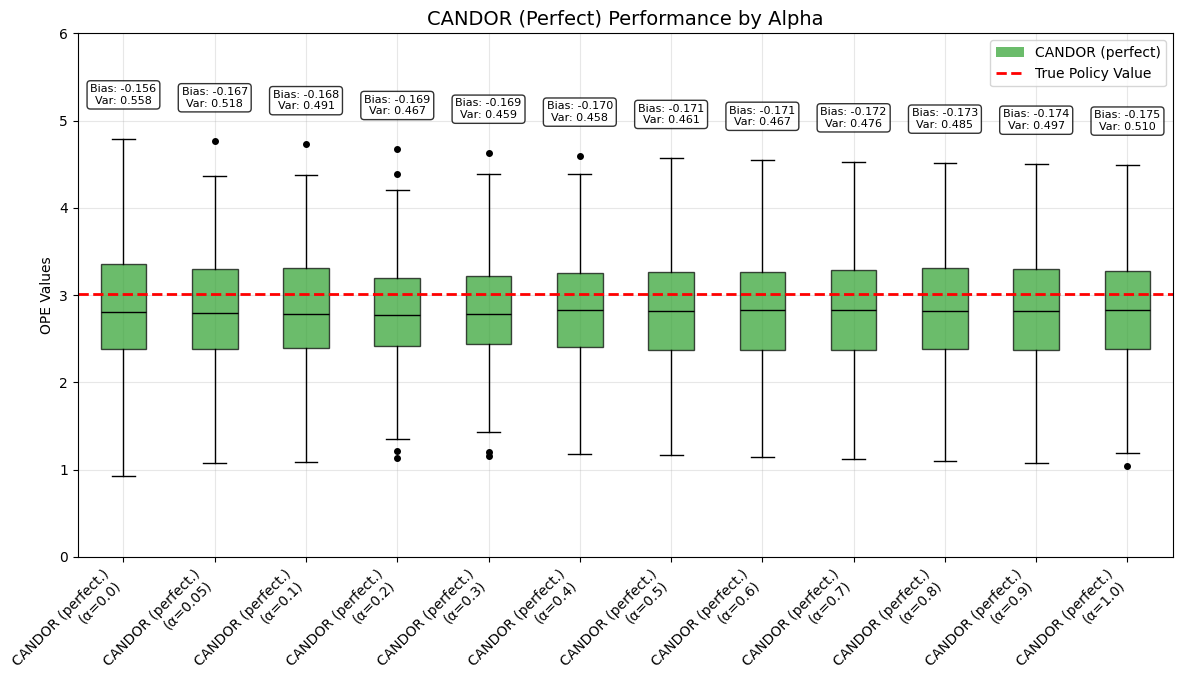

In [159]:
data = np.load('boxplot_data_alpha_3s5a.npz', allow_pickle=True)
alphas = data['alphas']
n_alphas = len(alphas)
true_value = data['true_value']

candor_perfect_data = data['CANDOR_perfect_estimates']

box_data = []
labels = []

for i, alpha in enumerate(alphas):
    box_data.append(candor_perfect_data[:, i, -1])
    labels.append(f'CANDOR (perfect.)\n(α={alpha})')

color = '#2ca02c'

fig, ax = plt.subplots(figsize=(12, 7))

bp = ax.boxplot(box_data, patch_artist=True, labels=labels)

for patch in bp['boxes']:
    patch.set_facecolor(color)
    patch.set_alpha(0.7)


for key in ['whiskers', 'caps', 'medians', 'fliers']:
    for item in bp[key]:
        item.set_color('black')
        if key == 'fliers':
            item.set_markerfacecolor('black')
            item.set_markeredgecolor('black')
            item.set_markersize(4)

ax.axhline(y=true_value, color='red', linestyle='--', linewidth=2, label='True Value')

legend_elements = [
    Patch(facecolor='#2ca02c', alpha=0.7, label='CANDOR (perfect)'),
    Line2D([0], [0], color='red', linestyle='--', lw=2, label='True Policy Value')
]
ax.legend(handles=legend_elements, loc='upper right')


global_max = np.max([np.max(d) for d in box_data if len(d) > 0])
global_min = np.min([np.min(d) for d in box_data if len(d) > 0])
y_offset = (global_max - global_min) * 0.02

for i, estimates in enumerate(box_data):
    if len(estimates) == 0: continue

    mean_est = np.mean(estimates)
    abs_bias = mean_est - true_value
    variance = np.var(estimates)

    y_pos = np.max(estimates) + y_offset

    ax.text(i + 1, y_pos + 0.3, f'Bias: {abs_bias:.3f}\nVar: {variance:.3f}',
            ha='center', va='bottom', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_title('CANDOR (Perfect) Performance by Alpha', fontsize=14)
ax.set_ylabel('OPE Values', fontsize=10)
ax.grid(True, linestyle='-', alpha=0.3)
plt.ylim([0, 6])

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('CANDOR (Perfect) Alpha Boxplot.png', dpi=300)
plt.show()

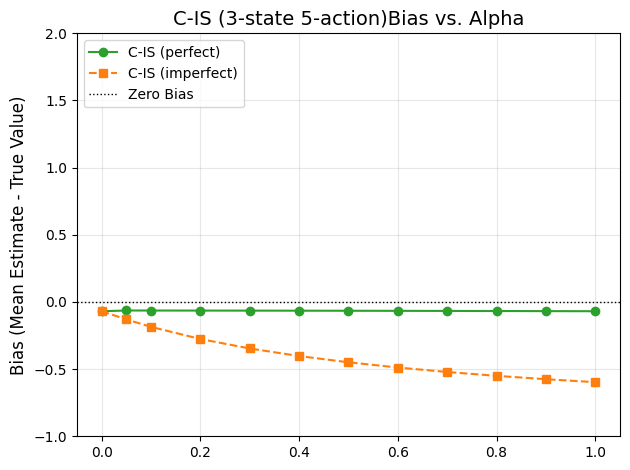

In [168]:
data = np.load('boxplot_data_alpha_3s5a.npz', allow_pickle=True)
imperfect_data_max_budget = data['CIS_imperfect_estimates'][:, :, -1]
perfect_data_max_budget = data['CIS_perfect_estimates'][:, :, -1]

imperfect_bias = np.mean(imperfect_data_max_budget, axis=0) - true_value
perfect_bias = np.mean(perfect_data_max_budget, axis=0) - true_value

plt.plot(alphas, perfect_bias, marker='o', linestyle='-', color='#2ca02c', label='C-IS (perfect)')
plt.plot(alphas, imperfect_bias, marker='s', linestyle='--', color='#ff7f0e', label='C-IS (imperfect)')

plt.axhline(y=0, color='black', linestyle=':', linewidth=1, label='Zero Bias')

plt.title(f'C-IS (3-state 5-action)Bias vs. Alpha', fontsize=14)
plt.ylabel('Bias (Mean Estimate - True Value)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='-', alpha=0.3)

plt.ylim([-1, 2])
plt.tight_layout()
plt.savefig('CIS_Bias_Alpha.png', dpi=300)
plt.show()

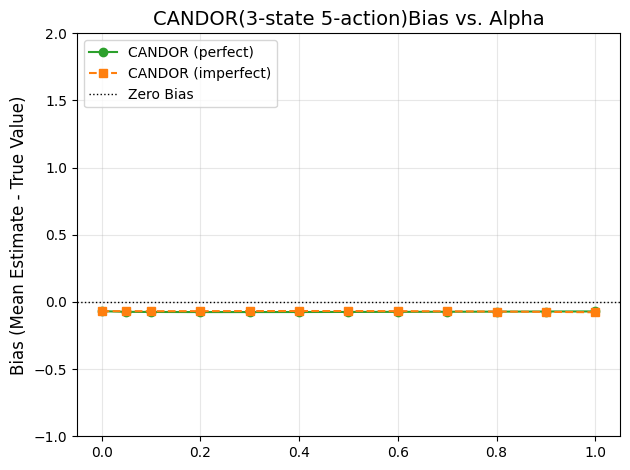

In [169]:
data = np.load('boxplot_data_alpha_3s5a.npz', allow_pickle=True)
imperfect_data_max_budget = data['CANDOR_imperfect_estimates'][:, :, -1]
perfect_data_max_budget = data['CANDOR_perfect_estimates'][:, :, -1]

imperfect_bias = np.mean(imperfect_data_max_budget, axis=0) - true_value
perfect_bias = np.mean(perfect_data_max_budget, axis=0) - true_value

plt.plot(alphas, perfect_bias, marker='o', linestyle='-', color='#2ca02c', label='CANDOR (perfect)')
plt.plot(alphas, imperfect_bias, marker='s', linestyle='--', color='#ff7f0e', label='CANDOR (imperfect)')

plt.axhline(y=0, color='black', linestyle=':', linewidth=1, label='Zero Bias')

plt.title(f'CANDOR(3-state 5-action)Bias vs. Alpha', fontsize=14)
plt.ylabel('Bias (Mean Estimate - True Value)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='-', alpha=0.3)

plt.ylim([-1, 2])
plt.tight_layout()
plt.savefig('CANDOR_Bias_Alpha.png', dpi=300)
plt.show()

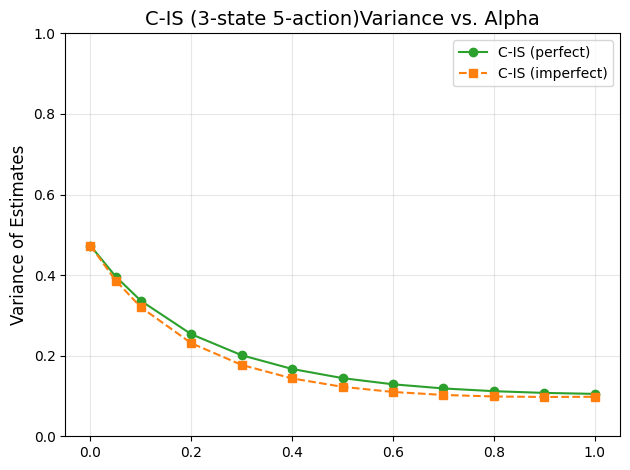

In [170]:
data = np.load('boxplot_data_alpha_3s5a.npz', allow_pickle=True)
imperfect_data_max_budget = data['CIS_imperfect_estimates'][:, :, -1]
perfect_data_max_budget = data['CIS_perfect_estimates'][:, :, -1]

# Variance = Var(V_hat)
imperfect_var = np.var(imperfect_data_max_budget, axis=0)
perfect_var = np.var(perfect_data_max_budget, axis=0)

plt.plot(alphas, perfect_var, marker='o', linestyle='-', color='#2ca02c', label='C-IS (perfect)')
plt.plot(alphas, imperfect_var, marker='s', linestyle='--', color='#ff7f0e', label='C-IS (imperfect)')

plt.title(f'C-IS (3-state 5-action)Variance vs. Alpha', fontsize=14)
plt.ylabel('Variance of Estimates', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='-', alpha=0.3)

plt.ylim([0, 1])
plt.tight_layout()
plt.savefig('CIS_Variance_Alpha.png', dpi=300)
plt.show()

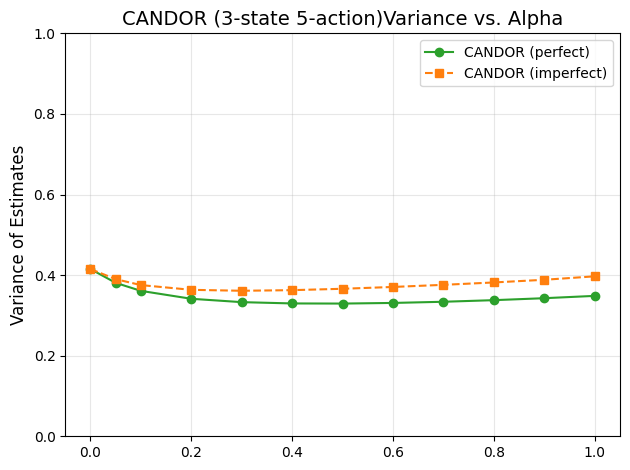

In [171]:
data = np.load('boxplot_data_alpha_3s5a.npz', allow_pickle=True)
imperfect_data_max_budget = data['CANDOR_imperfect_estimates'][:, :, -1]
perfect_data_max_budget = data['CANDOR_perfect_estimates'][:, :, -1]

# Variance = Var(V_hat)
imperfect_var = np.var(imperfect_data_max_budget, axis=0)
perfect_var = np.var(perfect_data_max_budget, axis=0)

plt.plot(alphas, perfect_var, marker='o', linestyle='-', color='#2ca02c', label='CANDOR (perfect)')
plt.plot(alphas, imperfect_var, marker='s', linestyle='--', color='#ff7f0e', label='CANDOR (imperfect)')

plt.title(f'CANDOR (3-state 5-action)Variance vs. Alpha', fontsize=14)
plt.ylabel('Variance of Estimates', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='-', alpha=0.3)

plt.ylim([0, 1])
plt.tight_layout()
plt.savefig('CANDOR_Variance_Alpha.png', dpi=300)
plt.show()

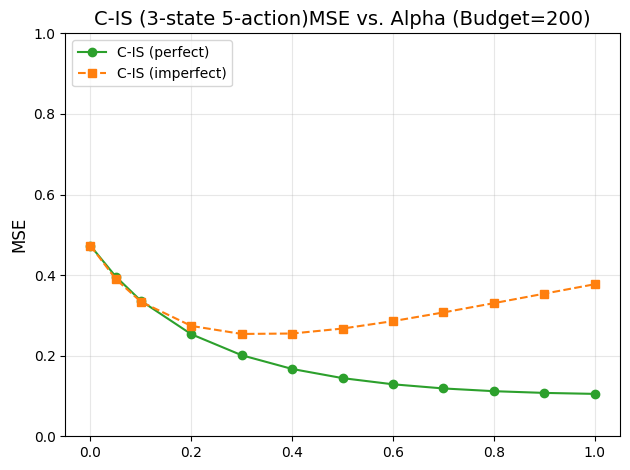

In [172]:
data = np.load('boxplot_data_alpha_3s5a.npz', allow_pickle=True)
alphas = data['alphas']
true_value = data['true_value']
imperfect_data_max_budget = data['CIS_imperfect_estimates'][:, :, -1]
perfect_data_max_budget = data['CIS_perfect_estimates'][:, :, -1]

imperfect_bias = np.mean(imperfect_data_max_budget, axis=0) - true_value
perfect_bias = np.mean(perfect_data_max_budget, axis=0) - true_value
imperfect_var = np.var(imperfect_data_max_budget, axis=0)
perfect_var = np.var(perfect_data_max_budget, axis=0)

# MSE = var + bias^2
imperfect_mse = (imperfect_bias**2) + imperfect_var
perfect_mse = (perfect_bias**2) + perfect_var

plt.plot(alphas, perfect_mse, marker='o', linestyle='-', color='#2ca02c', label='C-IS (perfect)')
plt.plot(alphas, imperfect_mse, marker='s', linestyle='--', color='#ff7f0e', label='C-IS (imperfect)')

plt.title(f'C-IS (3-state 5-action)MSE vs. Alpha (Budget={data["budgets"][-1]})', fontsize=14)
plt.ylabel('MSE', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='-', alpha=0.3)
plt.ylim([0,1])

plt.tight_layout()
plt.savefig('CIS_MSE_Alpha.png', dpi=300)
plt.show()

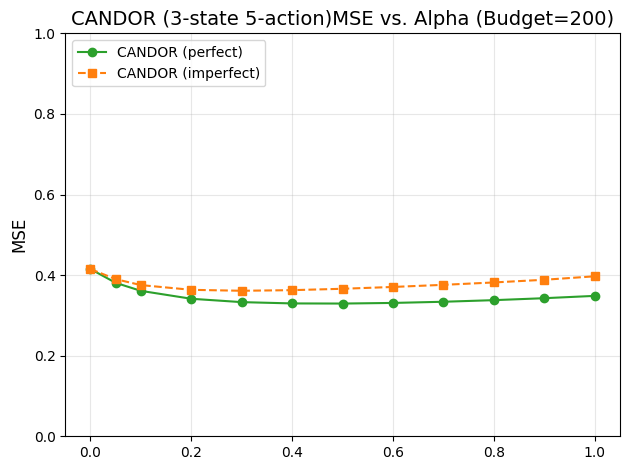

In [173]:
data = np.load('boxplot_data_alpha_3s5a.npz', allow_pickle=True)
alphas = data['alphas']
true_value = data['true_value']
imperfect_data_max_budget = data['CANDOR_imperfect_estimates'][:, :, -1]
perfect_data_max_budget = data['CANDOR_perfect_estimates'][:, :, -1]

imperfect_bias = np.mean(imperfect_data_max_budget, axis=0) - true_value
perfect_bias = np.mean(perfect_data_max_budget, axis=0) - true_value
imperfect_var = np.var(imperfect_data_max_budget, axis=0)
perfect_var = np.var(perfect_data_max_budget, axis=0)

# MSE = var + bias^2
imperfect_mse = (imperfect_bias**2) + imperfect_var
perfect_mse = (perfect_bias**2) + perfect_var

plt.plot(alphas, perfect_mse, marker='o', linestyle='-', color='#2ca02c', label='CANDOR (perfect)')
plt.plot(alphas, imperfect_mse, marker='s', linestyle='--', color='#ff7f0e', label='CANDOR (imperfect)')

plt.title(f'CANDOR (3-state 5-action)MSE vs. Alpha (Budget={data["budgets"][-1]})', fontsize=14)
plt.ylabel('MSE', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='-', alpha=0.3)
plt.ylim([0,1])

plt.tight_layout()
plt.savefig('CANDOR_MSE_Alpha.png', dpi=300)
plt.show()

/var/folders/sg/d0yh45390j9ct1_zwp6r1qx40000gn/T/ipykernel_3001/1671012850.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, patch_artist=True, labels=labels)


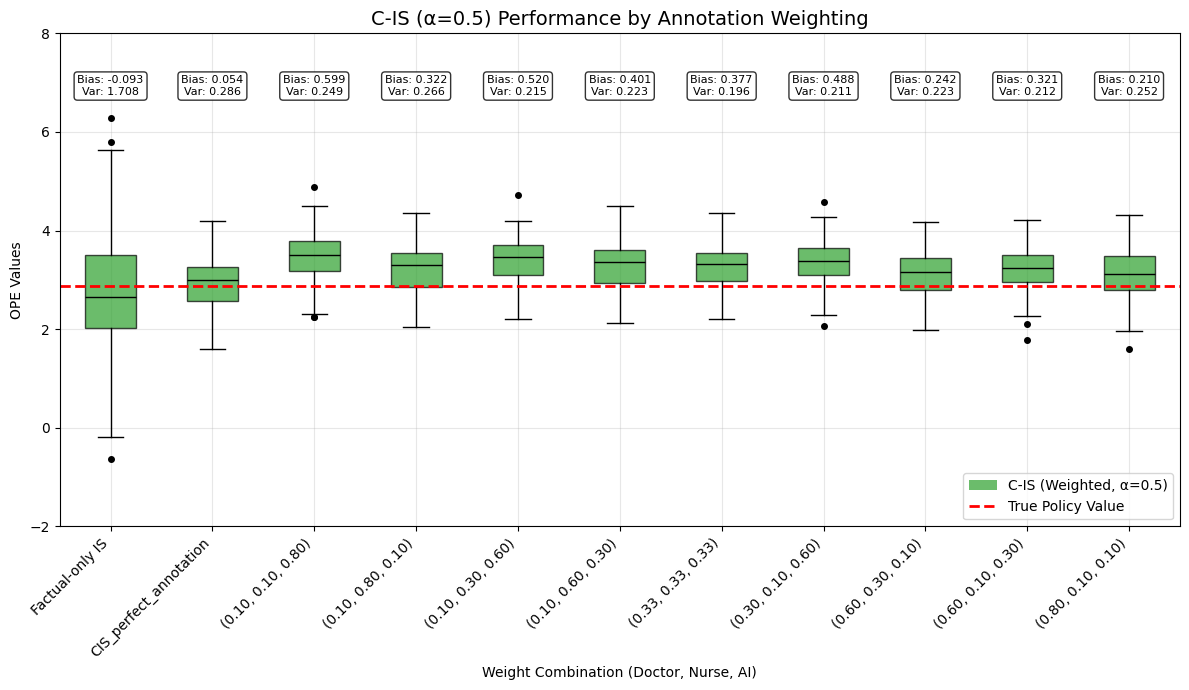

In [74]:
data = np.load('weighted_ann.npz', allow_pickle=True)
data_p = np.load('boxplot_data_alpha.npz', allow_pickle=True)

weights_data = data['weight_combinations']
budgets = data['budgets']
true_value = data['true_value']
cis_data = data['CIS_weighted_estimates']
is_baseline_data = data['IS_estimates']
cis_perfect_data = data_p['CIS_perfect_estimates'][:,6,-1]

n_weights = len(weights_data)
max_budget = budgets[-1]

box_data = []
labels = []

box_data.insert(0, is_baseline_data)
labels.insert(0, 'Factual-only IS')
box_data.insert(1, cis_perfect_data)
labels.insert(1, 'CIS_perfect_annotation')

for i, weight_vec in enumerate(weights_data):
    data_slice = cis_data[:, i, -1]
    box_data.append(data_slice)

    label_str = f'({weight_vec[0]:.2f}, {weight_vec[1]:.2f}, {weight_vec[2]:.2f})'
    labels.append(label_str)

color = '#2ca02c'

fig, ax = plt.subplots(figsize=(12, 7))

bp = ax.boxplot(box_data, patch_artist=True, labels=labels)

for patch in bp['boxes']:
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for key in ['whiskers', 'caps', 'medians', 'fliers']:
    for item in bp[key]:
        item.set_color('black')
        if key == 'fliers':
            item.set_markerfacecolor('black')
            item.set_markeredgecolor('black')
            item.set_markersize(4)

ax.axhline(y=true_value, color='red', linestyle='--', linewidth=2, label='True Value')

legend_elements = [
    Patch(facecolor=color, alpha=0.7, label='C-IS (Weighted, α=0.5)'),
    Line2D([0], [0], color='red', linestyle='--', lw=2, label='True Policy Value')
]
ax.legend(handles=legend_elements, loc='lower right')

global_max = np.max([np.max(d) for d in box_data if len(d) > 0])
global_min = np.min([np.min(d) for d in box_data if len(d) > 0])
y_offset = (global_max - global_min) * 0.02

text_baseline = max(global_max, true_value)

for i, estimates in enumerate(box_data):
    if len(estimates) == 0: continue

    mean_est = np.mean(estimates)
    abs_bias = mean_est - true_value
    variance = np.var(estimates)

    y_pos = text_baseline + y_offset

    ax.text(i + 1, y_pos + 0.3, f'Bias: {abs_bias:.3f}\nVar: {variance:.3f}',
            ha='center', va='bottom', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_title(f'C-IS (α=0.5) Performance by Annotation Weighting', fontsize=14)
ax.set_ylabel('OPE Values', fontsize=10)
ax.set_xlabel('Weight Combination (Doctor, Nurse, AI)', fontsize=10)
ax.grid(True, linestyle='-', alpha=0.3)

plt.ylim([-2, 8])

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('CIS_Weighted_Boxplot.png', dpi=300)
plt.show()

/var/folders/sg/d0yh45390j9ct1_zwp6r1qx40000gn/T/ipykernel_47533/3444134378.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, patch_artist=True, labels=labels)


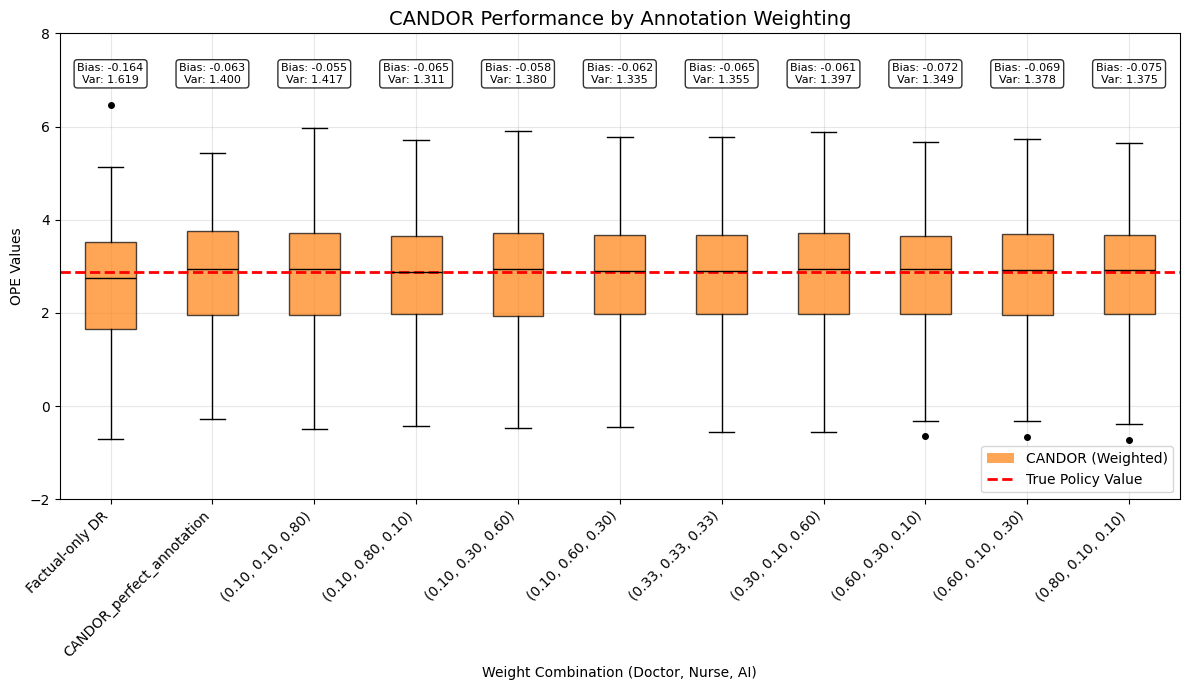

In [52]:
data = np.load('weighted_ann.npz', allow_pickle=True)
data_p = np.load('boxplot_data_alpha.npz', allow_pickle=True)

weights_data = data['weight_combinations']
budgets = data['budgets']
true_value = data['true_value']
candor_data = data['CANDOR_weighted_estimates']
dr_baseline_data = data['DR_estimates']
dr_perfect_data = data_p['CANDOR_perfect_estimates'][:,-1]

n_weights = len(weights_data)
max_budget = budgets[-1]

box_data = []
labels = []
box_data.insert(0, dr_baseline_data)
labels.insert(0, 'Factual-only DR')
box_data.insert(1, dr_perfect_data)
labels.insert(1, 'CANDOR_perfect_annotation')

for i, weight_vec in enumerate(weights_data):
    data_slice = candor_data[:, i, -1]
    box_data.append(data_slice)

    label_str = f'({weight_vec[0]:.2f}, {weight_vec[1]:.2f}, {weight_vec[2]:.2f})'
    labels.append(label_str)

color = '#ff7f0e'

fig, ax = plt.subplots(figsize=(12, 7))

bp = ax.boxplot(box_data, patch_artist=True, labels=labels)

for patch in bp['boxes']:
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for key in ['whiskers', 'caps', 'medians', 'fliers']:
    for item in bp[key]:
        item.set_color('black')
        if key == 'fliers':
            item.set_markerfacecolor('black')
            item.set_markeredgecolor('black')
            item.set_markersize(4)

ax.axhline(y=true_value, color='red', linestyle='--', linewidth=2, label='True Value')

legend_elements = [
    Patch(facecolor=color, alpha=0.7, label='CANDOR (Weighted)'),
    Line2D([0], [0], color='red', linestyle='--', lw=2, label='True Policy Value')
]
ax.legend(handles=legend_elements, loc='lower right')

global_max = np.max([np.max(d) for d in box_data if len(d) > 0])
global_min = np.min([np.min(d) for d in box_data if len(d) > 0])
y_offset = (global_max - global_min) * 0.02

text_baseline = max(global_max, true_value)

for i, estimates in enumerate(box_data):
    if len(estimates) == 0: continue

    mean_est = np.mean(estimates)
    abs_bias = mean_est - true_value
    variance = np.var(estimates)

    y_pos = text_baseline + y_offset

    ax.text(i + 1, y_pos + 0.3, f'Bias: {abs_bias:.3f}\nVar: {variance:.3f}',
            ha='center', va='bottom', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_title(f'CANDOR Performance by Annotation Weighting', fontsize=14)
ax.set_ylabel('OPE Values', fontsize=10)
ax.set_xlabel('Weight Combination (Doctor, Nurse, AI)', fontsize=10)
ax.grid(True, linestyle='-', alpha=0.3)

plt.ylim([-2, 8])

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('CANDOR_Weighted_Boxplot.png', dpi=300)
plt.show()